In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 10)

%matplotlib inline

### Plotting boounding boxes

In [9]:
def plot_bounding_box(dbox_data):
    """
    Plot bounding boxes

    dbox_data (tensor): a tensor of bounding boxes.
                        Format: [
                            [x_min, y_min, x_max, y_max, ...],
                            [x_min, y_min, x_max, y_max, ...],
                                        :
                                        :
                            [x_min, y_min, x_max, y_max, ...],
                        ]
    """
    # calculate height and width of all boxes
    # width = xmax-xmin+1
    # height = ymax-ymin+1

    width = dbox_data[:, 2] - dbox_data[:, 0] + 1
    height = dbox_data[:, 3] - dbox_data[:, 1] + 1

    color = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'w']
    fig = plt.figure(figsize=(8,8))

    ax = fig.add_subplot(111, aspect = 'equal')

    for i in range(len(dbox_data)):
        ax.add_patch(
            patches.Rectangle(
                (dbox_data[i,0], dbox_data[i, 1]),
                width[i],
                height[i],
                fill = False,
                color = color[i%len(color)],
                linewidth = 3,
                label = '{}'.format(i)
            )
        )

    ax.legend()

    plt.xticks(range(0, 1050, 50))
    plt.yticks(range(0, 1050, 50))
    plt.gca().axis('tight')
    plt.gca().invert_yaxis()

    plt.show()

    return

In [10]:
# example of bounding boxes representation
detections = torch.tensor(
    [
        [100, 100, 500, 600],
        [150, 320, 570, 620],
        [50,  150, 450, 800],
        [550, 300, 900, 500]
    ],
    dtype = torch.float32
)

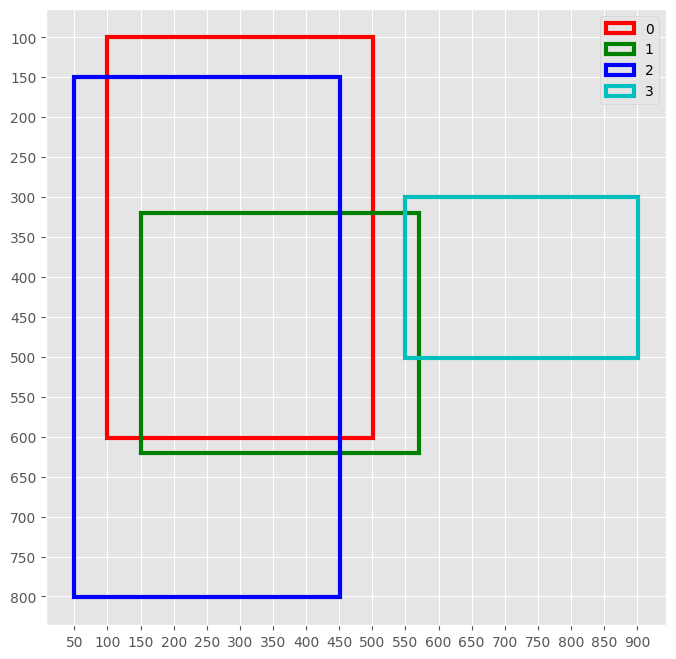

In [11]:
plot_bounding_box(detections)

### Computing IOU

In [12]:
def intersection_over_union(dbox_data, area = None):
    """
    Calculates IoU of the 0th indexed bounding box with the rest of the boxes ([1:]).

    Args:
        dbox_data (tensor): bounding boxes.
                    Format: [
                                [x_min, y_min, x_max, y_max, ...],
                                [x_min, y_min, x_max, y_max, ...],
                                         :
                                         :
                                [x_min, y_min, x_max, y_max, ...],
                            ]

        area: Area of the bounding boxes. Default: None.
              If area is None, the function calculates the area and use it.
              Format: [area_of_bounding_box_1, area_of_bounding_box_2, ....]

    Returns:
        (tensor): IoU of the 0th indexed bounding box with the rest of the boxes. Length will be one less than
                     the number of bounding box.
    """

    # Calculate area if not provided
    if area is None:

        # calculate width and height
        width = dbox_data[:, 2] - dbox_data[:, 0] + 1 
        height = dbox_data[:, 3] - dbox_data[:, 1] + 1

        area = torch.multiply(width, height)

    # Identify the overlap box coordinates
    x_min = torch.maximum(dbox_data[0, 0], dbox_data[1:, 0])
    y_min = torch.maximum(dbox_data[0, 1], dbox_data[1:, 1])
    x_max = torch.minimum(dbox_data[0, 2], dbox_data[1:, 2])
    y_max = torch.minimum(dbox_data[0, 3], dbox_data[1:, 3])

    # Calculate width and height of overlapped regions and suppress negative values
    intersection_width = torch.clamp((x_max - x_min + 1), 0.0)
    intersection_height = torch.clamp((y_max - y_min + 1), 0.0)

    # IOU calculation
    intersection_area = intersection_width * intersection_height
    iou = intersection_area / (area[0] + area[1:] - intersection_area)

    return iou

In [13]:
# use the above detections to calculate IOU
iou = intersection_over_union(detections)
print(f"IoU: {iou}")

IoU: tensor([0.4307, 0.5213, 0.0000])


### Computing overlap

In [14]:
def overlap(dbox_data):
    # computing overlap box coordinates
    x_min = torch.maximum(dbox_data[0, 0], dbox_data[1:, 0])
    y_min = torch.maximum(dbox_data[0, 1], dbox_data[1:, 1])
    x_max = torch.minimum(dbox_data[0, 2], dbox_data[1:, 2])
    y_max = torch.minimum(dbox_data[0, 3], dbox_data[1:, 3])

    # calculate width and height of overlapped regions and supress negative values
    intersection_width = torch.clamp((x_max - x_min + 1), 0.0)
    intersection_height = torch.clamp((y_max - y_min + 1), 0.0)

    # calculate area of overlapped regions
    intersection_area = intersection_width * intersection_height

    # calculate height and width of box 0
    width = dbox_data[0, 2] - dbox_data[0, 0] + 1
    height = dbox_data[0, 3] - dbox_data[0, 1] + 1

    # calculate total area occupied between all pairs
    area_ref = width * height

    # calculate overlap
    overlap = intersection_area/area_ref

    return overlap


In [16]:
overlap_size = overlap(detections)
print(f"Total overlap: {overlap_size}")

Total overlap: tensor([0.4909, 0.7880, 0.0000])
